# Persistence — auditable model artifact and reproducible inference


## Goal
Train a final pipeline, persist it as an auditable artifact, inspect the manifest/environment/checksums, reload it, reproduce predictions, and generate an inference report. This demo uses a temporary directory so it is safe to execute repeatedly.


In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEMO_TEST = os.getenv("MLCORE_DEMO_TEST") == "1"

def balanced_fold_labels(y, n_splits):
    """Demo-only external memberships. Production partition generation belongs to BioSieve."""
    y = np.asarray(y)
    folds = np.empty(len(y), dtype=int)
    for label in np.unique(y):
        idx = np.flatnonzero(y == label)
        folds[idx] = np.arange(len(idx)) % n_splits
    return folds

from pathlib import Path
import tempfile
from sklearn.datasets import make_classification
from mlcore import train, load_model, inspect_artifact, verify_artifact, evaluate
from mlcore.datasets import DatasetBundle


In [2]:
X,y=make_classification(n_samples=140 if DEMO_TEST else 280,n_features=12,n_informative=8,class_sep=1.1,random_state=101)
ids=[f"persist_{i:04d}" for i in range(len(y))]
dataset=DatasetBundle(X=X,y=y,sample_ids=ids,feature_names=[f"f{i}" for i in range(X.shape[1])])
with tempfile.TemporaryDirectory() as tmp:
    artifact_path=Path(tmp)/"model_artifact"
    trained=train(dataset=dataset,algorithm="logistic_regression",random_state=42,artifact_path=artifact_path)
    before=trained.model.predict(dataset.X)
    verified=verify_artifact(artifact_path)
    manifest=inspect_artifact(artifact_path)
    loaded=load_model(artifact_path)
    pred=loaded.predict_result(dataset.X,feature_names=dataset.feature_names,sample_ids=dataset.sample_ids)
    evaluation=evaluate(dataset=dataset,model=loaded,metrics=("accuracy","balanced_accuracy","mcc","roc_auc","pr_auc","log_loss"))
    files=sorted(p.name for p in artifact_path.iterdir())
    report=pd.DataFrame({"sample_id":ids,"y_true":y,"y_pred":pred.predictions,"p_positive":pred.positive_probabilities()})
    exact_roundtrip=np.array_equal(before,pred.predictions)
print("Artifact files:",files)
print("Manifest type:",manifest.artifact_type); print(pd.Series(evaluation.metrics).round(4))


Artifact files: ['checksums.sha256', 'environment.json', 'feature_schema.json', 'manifest.json', 'metrics.json', 'model.joblib', 'parameters.json', 'provenance.json', 'training_config.json']
Manifest type: model
accuracy             0.7750
balanced_accuracy    0.7748
mcc                  0.5505
roc_auc              0.8695
pr_auc               0.8788
log_loss             0.4528
dtype: float64


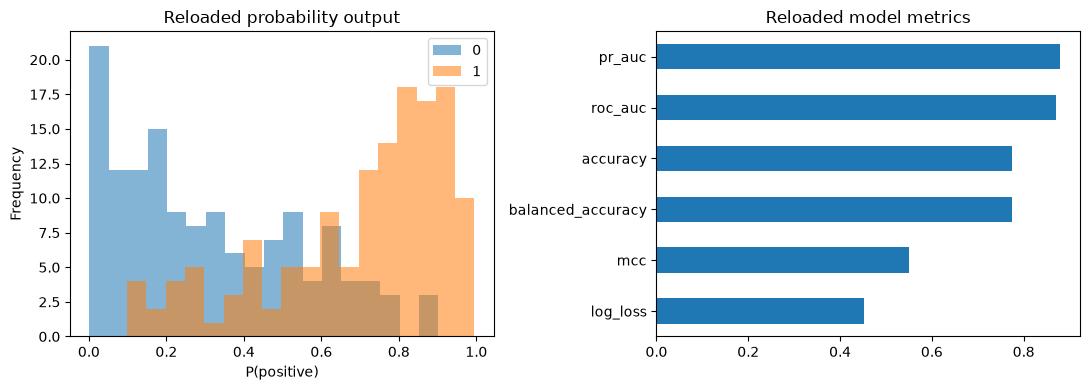

In [3]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
report.groupby("y_true").p_positive.plot.hist(alpha=.55,bins=18,ax=axes[0],legend=True); axes[0].set(title="Reloaded probability output",xlabel="P(positive)")
pd.Series(evaluation.metrics).sort_values().plot.barh(ax=axes[1]); axes[1].set_title("Reloaded model metrics")
plt.tight_layout(); FIGURE_COUNT=1


In [4]:
DEMO_CHECKS={
    "checksums_verified": bool(verified),
    "roundtrip_exact": exact_roundtrip,
    "manifest_available": getattr(manifest,"artifact_type",None)=="model",
    "structured_prediction": pred.sample_ids.shape[0]==dataset.n_samples,
    "artifact_is_auditable": {"manifest.json","model.joblib","environment.json","feature_schema.json","checksums.sha256"}.issubset(files),
    "evaluation_complete": set(evaluation.metrics)>={"accuracy","mcc","roc_auc"},
    "figure_created":FIGURE_COUNT==1,
}
assert all(DEMO_CHECKS.values()), DEMO_CHECKS
DEMO_CHECKS


{'checksums_verified': True,
 'roundtrip_exact': True,
 'manifest_available': True,
 'structured_prediction': True,
 'artifact_is_auditable': True,
 'evaluation_complete': True,
 'figure_created': True}